In [3]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk, ToolMessage
from langgraph.types import Command

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-pro",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


In [ ]:
#下面的案例需要使用deepseek-v4-pro模型 flash模型无法生成正确的结果

In [4]:
from langchain_core.messages import HumanMessage
from typing import NotRequired
from langchain.agents import create_agent, AgentState
from langchain.tools import tool, ToolRuntime
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()


class CustomState(AgentState):
    user_id: NotRequired[str]


@tool(parse_docstring=True)
def save_user_info(name: str, runtime: ToolRuntime) -> str:
    """
    将用户信息保存在长期记忆中

    Args:
        name: 用户名

    Returns:
    str: 保存状态
    """
    runtime.store.put(("users",), runtime.state["user_id"], {"name": name})
    return "saved"


@tool(parse_docstring=True)
def get_user_info(runtime: ToolRuntime) -> str:
    """
    从长期记忆中读取用户信息

    Returns:
        str: 用户信息
    """
    item = runtime.store.get(("users",), runtime.state["user_id"])
    return str(item.value) if item else "unknown"


agent = create_agent(
    model=model,
    tools=[save_user_info, get_user_info],
    store=store,
    system_prompt="用户提及个人信息时及时记录，用户询问个人信息时尝试用工具检索",
    state_schema=CustomState,
)
print("=" * 30, '-> 第一个会话（线程） <-', "=" * 30)
response1 = agent.invoke({
    "messages": [HumanMessage("你好，很高兴认识你，我是小花")],
    "user_id": "user-1"
})
for msg in response1["messages"]:
    msg.pretty_print()

print("=" * 30, '-> 第二个会话（线程） <-', "=" * 30)

response2 = agent.invoke({
    "messages": [HumanMessage("我是谁")],
    "user_id": "user-1"
})
for msg in response2["messages"]:
    msg.pretty_print()

============================== -> 第一个会话（线程） <- ==============================
================================ Human Message =================================

你好，很高兴认识你，我是小花
================================== Ai Message ==================================

你好小花！很高兴认识你～😊

我已经记下你的名字了，这样以后聊天会更亲切。今天有什么我可以帮你的吗？
Tool Calls:
  save_user_info (call_00_mUwfacUOiHR0XOrCaA9f4071)
 Call ID: call_00_mUwfacUOiHR0XOrCaA9f4071
  Args:
    name: 小花
================================= Tool Message =================================
Name: save_user_info

saved
================================== Ai Message ==================================

名字已经记好啦！有什么想聊的或者需要帮助的吗？🌸
============================== -> 第二个会话（线程） <- ==============================
================================ Human Message =================================

我是谁
================================== Ai Message ==================================

让我帮你查询一下你的信息。
Tool Calls:
  get_user_info (call_00_5VQBX46FbzUJjdgZqyok4312)
 Call ID: call_00_5VQBX46

其中，CustomState扩展了 Agent 的标准状态。除了默认的 messages （历史消息列表）之外，还额
外增加了一个 user_id 字段。这样，Agent 在运行过程中随时随地都能知道当前和它说话的用户 ID 是
什么。

In [5]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


② 基于PostgresStore的长期记忆


In [7]:
from typing import NotRequired
from langchain.agents import create_agent, AgentState
from langchain.tools import tool, ToolRuntime
from langgraph.store.postgres import PostgresStore

import os

DB_URI = os.getenv("POSTGRES_URL")


class CustomState(AgentState):
    user_id: NotRequired[str]


@tool(parse_docstring=True)
def save_user_info(name: str, runtime: ToolRuntime) -> str:
    """
    将用户信息保存在长期记忆中

    Args:
        name: 用户名

    Returns:
        str: 保存状态
    """
    runtime.store.put(("users",), runtime.state["user_id"], {"name": name})
    return "saved"


@tool(parse_docstring=True)
def get_user_info(runtime: ToolRuntime) -> str:
    """
    从长期记忆中读取用户信息

    Returns:
        str: 用户信息
    """
    item = runtime.store.get(("users",), runtime.state["user_id"])
    return str(item.value) if item else "unknown"


with PostgresStore.from_conn_string(DB_URI) as store:
    store.setup()
    agent = create_agent(
        model=model,
        tools=[save_user_info, get_user_info],
        store=store,
        system_prompt="用户提及个人信息时及时记录，用户询问个人信息时尝试用工具检索",
        state_schema=CustomState,
    )
    print("=" * 30, '-> 第一个会话（线程） <-', "=" * 30)
    response1 = agent.invoke({
        "messages": "你好，很高兴认识你，我是小花",
        "user_id": "user-1"
    })
    for msg in response1["messages"]:
        msg.pretty_print()
    print("=" * 30, '-> 第二个会话（线程） <-', "=" * 30)
    response2 = agent.invoke({
        "messages": "我是谁",
        "user_id": "user-1"
    })
    for msg in response2["messages"]:
        msg.pretty_print()

============================== -> 第一个会话（线程） <- ==============================
================================ Human Message =================================

你好，很高兴认识你，我是小花
================================== Ai Message ==================================

你好，小花！很高兴认识你呀！😊 让我把你的名字记下来，这样以后就能记得你了～
Tool Calls:
  save_user_info (call_00_qSBRQv81ALcGnqTbdyJw5347)
 Call ID: call_00_qSBRQv81ALcGnqTbdyJw5347
  Args:
    name: 小花
================================= Tool Message =================================
Name: save_user_info

saved
================================== Ai Message ==================================

已经记住你了，小花！以后有什么需要帮忙的，随时可以找我聊哦～你今天想聊点什么呢？😄
============================== -> 第二个会话（线程） <- ==============================
================================ Human Message =================================

我是谁
================================== Ai Message ==================================

让我查一下您的信息。
Tool Calls:
  get_user_info (call_00_YzWHCh1o3XhDLx0HGt5g8901)
 Call ID: call_00_YzWHC

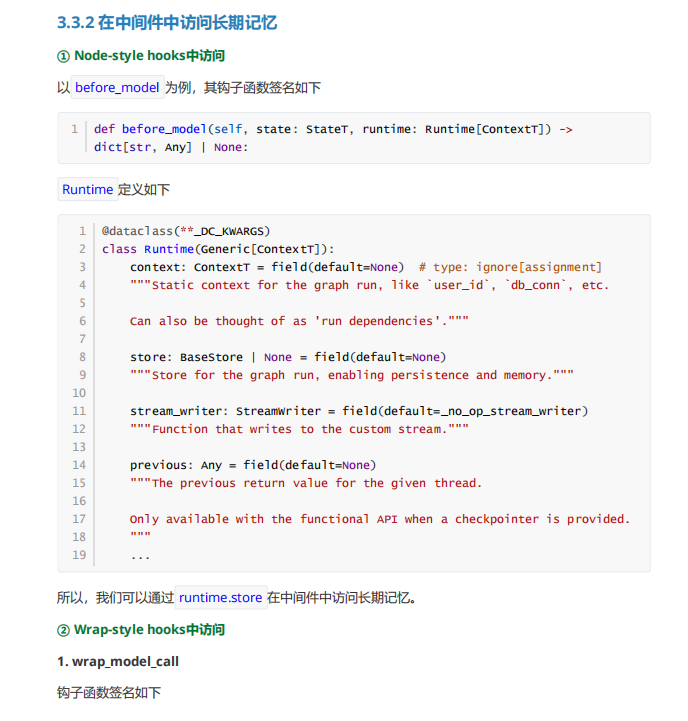
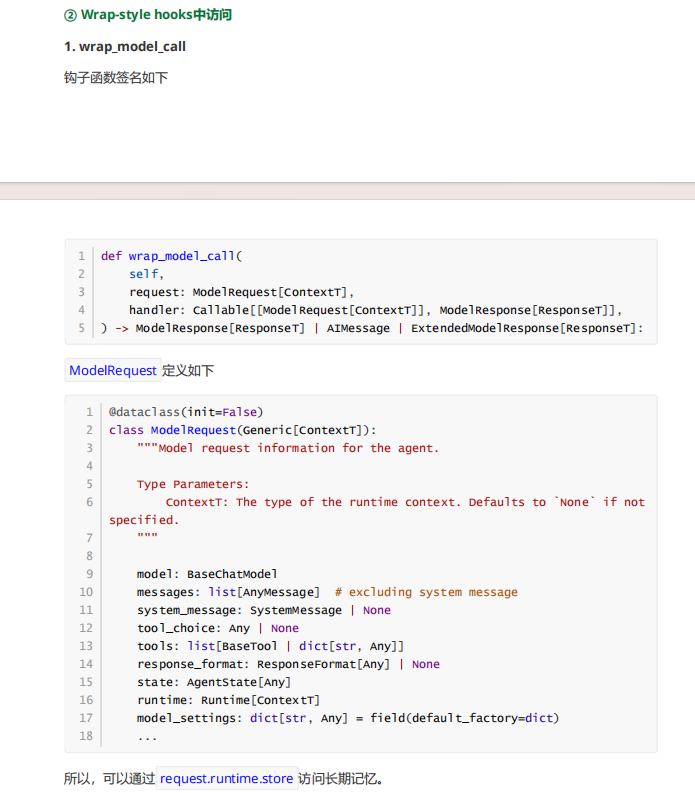
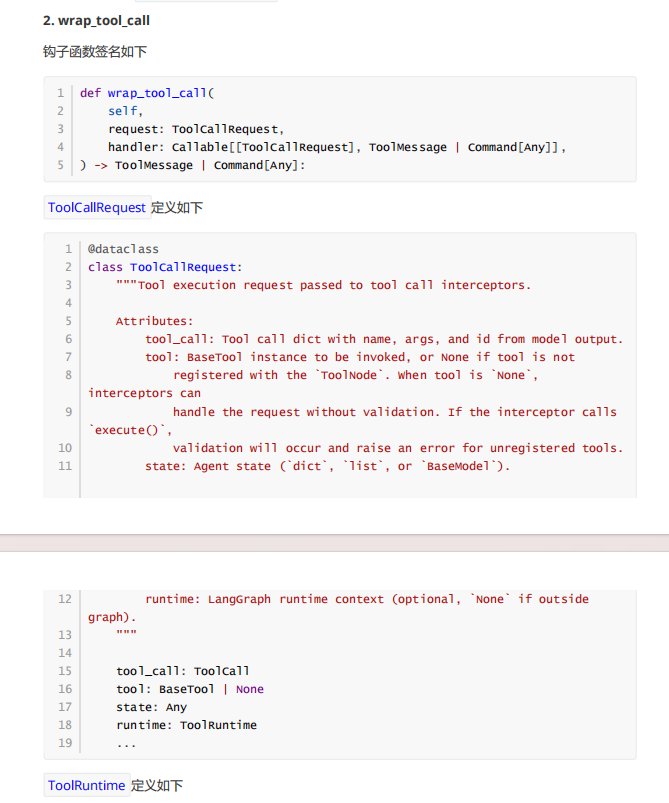
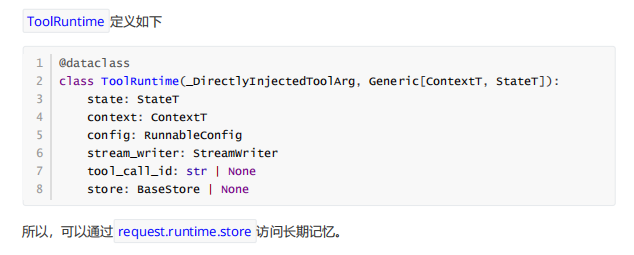
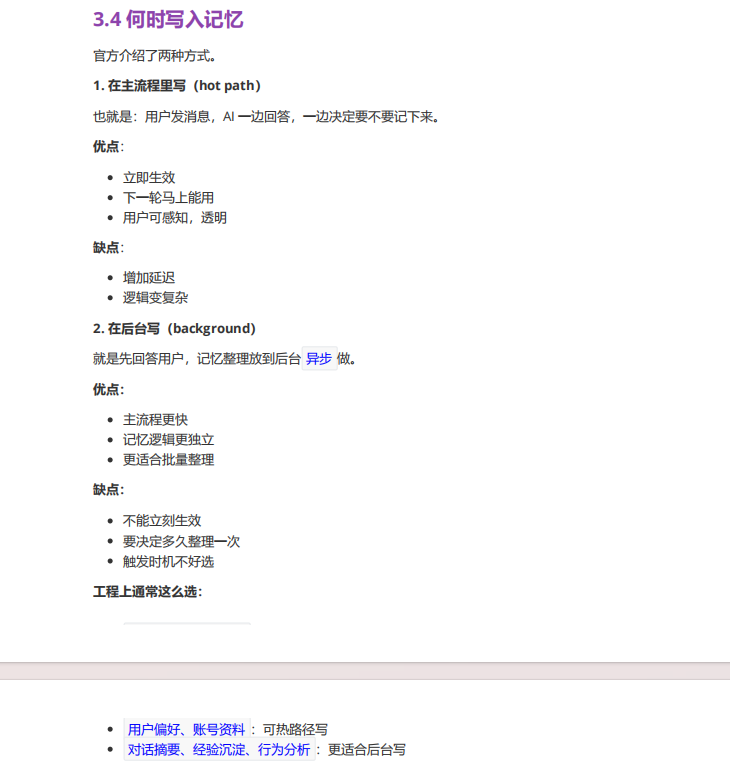
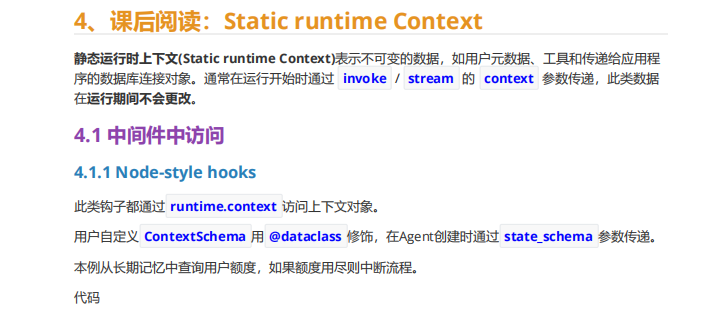

In [13]:
from dataclasses import dataclass
from typing import Any
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, AgentState, hook_config
from langchain.messages import AIMessage
from langgraph.runtime import Runtime
from langgraph.store.memory import InMemoryStore
from dotenv import load_dotenv
from loguru import logger

load_dotenv()
store = InMemoryStore()
namespace = ("users", "credits")
key1 = 'Ada Lovelace'
value1 = {
    "tokens_credit_left": 5000,
    "user_level": 5
}
key2 = 'Blackwell'
value2 = {
    "tokens_credit_left": 2999,
    "user_level": 5
}
key3 = 'Ampere'
value3 = {
    "tokens_credit_left": 1000,
    "user_level": 5
}
store.put(namespace, key1, value1)
store.put(namespace, key2, value2)
store.put(namespace, key3, value3)


@dataclass
class UserContext:
    username: str


class CheckCredit(AgentMiddleware):

    #模型运行前获取用户额度并检查是否足够 不足则直接跳转到结束状态
    @hook_config(can_jump_to=["end"])
    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        store = runtime.store
        context = runtime.context
        username = context.username
        credit = store.get(namespace, username)
        if not credit:
            return {
                "jump_to": "end",
                "messages": AIMessage("您尚未注册~")
            }
        if credit.value["tokens_credit_left"] < 3000:
            return {
                "jump_to": "end",
                "messages": AIMessage(f"{username}额度不足，请充值")
            }
        return None

    # 模型运行后更新用户额度
    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        store = runtime.store
        context = runtime.context
        username = context.username
        credit = store.get(namespace, username)
        usage_metadata = state["messages"][-1].usage_metadata
        token_usage = usage_metadata["input_tokens"] + usage_metadata["output_tokens"] * 6
        credit.value["tokens_credit_left"] -= token_usage
        # 更新长期记忆
        store.put(namespace, username, credit.value)
        return None

    #模型运行结束后，记录用户额度变化
    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        store = runtime.store
        context = runtime.context
        username = context.username
        item = store.get(namespace, username)
        credit = item.value["tokens_credit_left"]
        logger.info(f"{username} 当前剩余额度：{credit}")
        return None


agent = create_agent(
    model="deepseek-chat",
    middleware=[CheckCredit()],
    store=store,
    context_schema=UserContext
)

response1 = agent.invoke(
    {"messages": ["你好啊，你知道 Ada Lovelace 的贡献吗？"]},
    context=UserContext(username="Ada Lovelace")
)
print("=" * 30, '-> Ada Lovelace messages <-', '=' * 30)
for msg in response1["messages"]:
    msg.pretty_print()
response2 = agent.invoke(
    {"messages": ["你好啊，你知道 Blackwell 的贡献吗？"]},
    context=UserContext(username="Blackwell")
)
print("=" * 30, '-> Blackwell messages <-', '=' * 30)
for msg in response2["messages"]:
    msg.pretty_print()

2026-07-19 11:18:56.978 | INFO     | __main__:after_agent:80 - Ada Lovelace 当前剩余额度：3885
2026-07-19 11:18:56.981 | INFO     | __main__:after_agent:80 - Blackwell 当前剩余额度：2999


============================== -> Ada Lovelace messages <- ==============================
================================ Human Message =================================

你好啊，你知道 Ada Lovelace 的贡献吗？
================================== Ai Message ==================================

你好！当然知道～Ada Lovelace（艾达·洛夫莱斯）是数学和计算机科学史上非常重要的人物。她通常被认为是**世界上第一位程序员**。

她的主要贡献是：

1.  **编写了第一份算法**：在19世纪40年代，她为查尔斯·巴贝奇设计的分析机（一种早期的机械通用计算机）编写了计算伯努利数的算法。这被认为是世界上第一个专门为计算机设计的程序。

2.  **提出了“通用计算机”的概念**：她预见到机器不仅可以处理纯数字，还能处理音乐、图像等符号，这个想法远远超前于她的时代。

3.  **区分了数据和程序**：她指出分析机可以操作符号和数字，这为后来“存储程序概念”打下了思想基础。

是不是很有意思？正因为这些早期贡献，IT界用她的名字命名了“Ada编程语言”。
============================== -> Blackwell messages <- ==============================
================================ Human Message =================================

你好啊，你知道 Blackwell 的贡献吗？
================================== Ai Message ==================================

Blackwell额度不足，请充值


4.1.2 Wrap-style hooks
① wrap_model_call
本例通过 context 中记录的用户身份信息调整暴露给模型的工具集。
此处更改模型请求的方法是 transient request update ，见上文短期记忆 2-4-2

In [6]:
from dataclasses import dataclass
from typing import Callable
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, ModelResponse, ModelRequest
from langchain.messages import AIMessage, ToolMessage
from langchain.tools import tool
from langgraph.store.memory import InMemoryStore
from dotenv import load_dotenv
from loguru import logger

load_dotenv()
store = InMemoryStore()
namespace = ("users", "credits")
key1 = 'Ada Lovelace'
value1 = {
    "tokens_left": 3000,  # 剩余大模型token额度
    "get_weather": "yes",  # 是否认证天气查询服务
    "get_news": "no"  # 是否认证网络爬虫服务，用于查询新闻
}
key2 = 'Blackwell'
value2 = {
    "tokens_left": 2000,  # 剩余大模型token额度
    "get_weather": "no",  # 是否认证天气查询服务
    "get_news": "yes"  # 是否认证网络爬虫服务，用于查询新闻
}
key3 = 'Ampere'
value3 = {
    "tokens_left": 3000,  # 剩余大模型token额度
    "get_weather": "yes",  # 是否认证天气查询服务
    "get_news": "yes"  # 是否认证网络爬虫服务，用于查询新闻
}
store.put(namespace, key1, value1)
store.put(namespace, key2, value2)
store.put(namespace, key3, value3)


@tool
def get_weather(city: str):
    """
    查询指定城市当日天气

    Args:
        city: 城市名称
    """
    return f"{city} 今天天气不错"


@tool()
def get_news():
    """查询当日新闻"""

    return "美伊尚未达成停战协议"


@dataclass
class UserContext:
    username: str


class CheckCredit(AgentMiddleware):
    # 模型调用前检查用户额度, 仅授权用户调用工具 wrap_model_call会包裹模型的调用过程 ai每调用一次模型就会调用一次wrap_model_call 这次案例是因为会调用俩次 一次是工具调用 最后一次是总结输出
    def wrap_model_call(
            self,
            request: ModelRequest,
            handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        context = request.runtime.context
        store = request.runtime.store
        #判断当前是否是工具调用
        if isinstance(request.messages[-1], ToolMessage):
            return handler(request)
        value = store.get(namespace, context.username).value
        tools = []
        for tool in request.tools:
            tool_name = tool.name
            if value[tool_name] == "yes":
                tools.append(tool)
            else:
                logger.warning(f"{context.username} 无权调用 {tool_name}")
        # 更改调用请求携带的工具集，仅本次生效
        request = request.override(tools=tools)
        return handler(request)


agent = create_agent(
    model=model,
    middleware=[CheckCredit()],
    tools=[get_weather, get_news],
    store=store,
    context_schema=UserContext
)

response1 = agent.invoke(
    {"messages": ["你好啊，今天北京天气如何，今日有哪些新闻？"]},
    context=UserContext(username="Ada Lovelace")
)
print("=" * 30, '-> Ada Lovelace messages <-', '=' * 30)
for msg in response1["messages"]:
    msg.pretty_print()
response2 = agent.invoke(
    {"messages": ["你好啊，今天北京天气如何，今日有哪些新闻？"]},
    context=UserContext(username="Blackwell")
)
print("=" * 30, '-> Blackwell messages <-', '=' * 30)
for msg in response2["messages"]:
    msg.pretty_print()
response3 = agent.invoke(
    {"messages": ["你好啊，今天北京天气如何，今日有哪些新闻？"]},
    context=UserContext(username="Ampere")
)
print("=" * 30, '-> Ampere messages <-', '=' * 30)
for msg in response3["messages"]:
    msg.pretty_print()

2026-07-19 11:45:56.808 | WARNING  | __main__:wrap_model_call:79 - Ada Lovelace 无权调用 get_news
2026-07-19 11:46:00.167 | WARNING  | __main__:wrap_model_call:79 - Blackwell 无权调用 get_weather


============================== -> Ada Lovelace messages <- ==============================
================================ Human Message =================================

你好啊，今天北京天气如何，今日有哪些新闻？
================================== Ai Message ==================================

你好！我先帮你查一下北京今天的天气。不过，关于新闻查询的功能我暂时没有相关的工具，所以无法为你提供今日新闻。让我先查天气吧！
Tool Calls:
  get_weather (call_00_eMKtCaXXbNmruWU2UC6s9750)
 Call ID: call_00_eMKtCaXXbNmruWU2UC6s9750
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京 今天天气不错
================================== Ai Message ==================================

北京今天的天气不错！阳光明媚，适合出门活动。

不过很抱歉，目前我这边没有可用的新闻查询工具，所以无法为你获取今日新闻。如果你有其他需要，随时告诉我！😊
============================== -> Blackwell messages <- ==============================
================================ Human Message =================================

你好啊，今天北京天气如何，今日有哪些新闻？
================================== Ai Message ==============================

② wrap_tool_call
在上述案例的基础上，我们补充额度校验，和长期记忆更新。

In [9]:
from dataclasses import dataclass
from typing import Callable
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, ModelResponse, ModelRequest
from langchain.messages import AIMessage, ToolMessage
from langchain.tools import tool
from langgraph.store.memory import InMemoryStore
from dotenv import load_dotenv
from loguru import logger

load_dotenv()
store = InMemoryStore()
namespace = ("users", "credits")
key1 = 'Ada Lovelace'
value1 = {
    "tokens_left": 3000,  # 剩余大模型token额度
    "get_weather": "yes",  # 是否认证天气查询服务
    "get_news": "no"  # 是否认证网络爬虫服务，用于查询新闻
}
key2 = 'Blackwell'
value2 = {
    "tokens_left": 2000,  # 剩余大模型token额度
    "get_weather": "no",  # 是否认证天气查询服务
    "get_news": "yes"  # 是否认证网络爬虫服务，用于查询新闻
}
key3 = 'Ampere'
value3 = {
    "tokens_left": 3000,  # 剩余大模型token额度
    "get_weather": "yes",  # 是否认证天气查询服务
    "get_news": "yes"  # 是否认证网络爬虫服务，用于查询新闻
}
store.put(namespace, key1, value1)
store.put(namespace, key2, value2)
store.put(namespace, key3, value3)


@tool
def get_weather(city: str):
    """
    查询指定城市当日天气

    Args:
        city: 城市名称
    """
    return f"{city} 今天天气不错"


@tool()
def get_news():
    """查询当日新闻"""

    return "美伊尚未达成停战协议"


@dataclass
class UserContext:
    username: str


class CheckCredit(AgentMiddleware):
    # 模型调用前检查用户额度, 仅授权用户调用工具 wrap_model_call会包裹模型的调用过程 ai每调用一次模型就会调用一次wrap_model_call 这次案例是因为会调用俩次 一次是工具调用 最后一次是总结输出
    def wrap_model_call(
            self,
            request: ModelRequest,
            handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        context = request.runtime.context
        store = request.runtime.store
        #判断当前是否是工具调用
        if isinstance(request.messages[-1], ToolMessage):
            return handler(request)
        value = store.get(namespace, context.username).value
        tools = []
        for tool in request.tools:
            tool_name = tool.name
            if value[tool_name] == "yes":
                tools.append(tool)
            else:
                logger.warning(f"{context.username} 无权调用 {tool_name}")
        # 更改调用请求携带的工具集，仅本次生效
        request = request.override(tools=tools)
        return handler(request)

    # 工具调用前检查用户额度, 仅授权用户调用工具
    def wrap_tool_call(
            self,
            request: ModelRequest,
            handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        context = request.runtime.context
        store = request.runtime.store
        #获取调用额度
        value = store.get(namespace, context.username).value
        tokens_left = value["tokens_left"]
        if tokens_left <= 0:
            logger.warning(f"{context.username} 无调用额度")
            update = {
                "messages": [
                    ToolMessage(
                        content="额度不足，无法调用工具，请充值~",
                        tool_call_id=request.runtime.tool_call_id
                    )
                ]
            }
            return update
        else:
            ai_messages = request.state["messages"][-1]
            response_metadata = ai_messages.response_metadata
            token_usage = response_metadata.get("token_usage")
            value["tokens_left"] -= token_usage["total_tokens"]
            store.put(namespace, context.username, value)
            return handler(request)


agent = create_agent(
    model=model,
    middleware=[CheckCredit()],
    tools=[get_weather, get_news],
    store=store,
    context_schema=UserContext)

response1 = agent.invoke(
    {"messages": ["你好啊，今天北京天气如何，今日有哪些新闻？"]},
    context=UserContext(username="Ada Lovelace")
)
print("=" * 30, '-> Ada Lovelace messages <-', '=' * 30)
for msg in response1["messages"]:
    msg.pretty_print()
response2 = agent.invoke(
    {"messages": ["你好啊，今天北京天气如何，今日有哪些新闻？"]},
    context=UserContext(username="Blackwell")
)
print("=" * 30, '-> Blackwell messages <-', '=' * 30)
for msg in response2["messages"]:
    msg.pretty_print()
response3 = agent.invoke(
    {"messages": ["你好啊，今天北京天气如何，今日有哪些新闻？"]},
    context=UserContext(username="Ampere")
)
print("=" * 30, '-> Ampere messages <-', '=' * 30)
for msg in response3["messages"]:
    msg.pretty_print()

2026-07-19 12:23:41.409 | WARNING  | __main__:wrap_model_call:79 - Ada Lovelace 无权调用 get_news
2026-07-19 12:24:04.423 | WARNING  | __main__:wrap_model_call:79 - Blackwell 无权调用 get_weather


============================== -> Ada Lovelace messages <- ==============================
================================ Human Message =================================

你好啊，今天北京天气如何，今日有哪些新闻？
================================== Ai Message ==================================

你好！我来帮你查询今天北京的天气情况。不过关于新闻查询，我目前没有相关的新闻查询工具，只能帮你查天气哦。让我先查天气吧！
Tool Calls:
  get_weather (call_00_fUfedagl5EHBsqk1vg6M6309)
 Call ID: call_00_fUfedagl5EHBsqk1vg6M6309
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京 今天天气不错
================================== Ai Message ==================================

你好呀！🌤️

关于**北京今天的天气**：今天天气不错！

不过关于**今日新闻**，很抱歉，我目前没有新闻查询的功能工具，无法为你获取今天的新闻内容。建议你可以通过新闻类 App 或网站来查看最新的新闻资讯哦！

还有其他我可以帮你的吗？
============================== -> Blackwell messages <- ==============================
================================ Human Message =================================

你好啊，今天北京天气如何，今日有哪些新闻？
=================================

4.1.3 特殊的便捷中间件dynamic_prompt
如前所述，@dynamic_prompt底层实现机制和通用钩子函数是统一的，对于动态提示词处理提供了更
加便捷的入口。
本例通过静态上下文中携带的用户信息，动态更改系统提示词。

In [10]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest
from langgraph.store.memory import InMemoryStore
from dotenv import load_dotenv
from loguru import logger

load_dotenv()
# 准备历史记忆
namespace = ("users", "preferences")
key1 = "Ada Lovelace"
value1 = {
    "chat_preferences": [
        "不喜欢啰嗦",
        "尽可能用最精简的文字解释清楚"
    ]
}
key2 = "Blackwell"
value2 = {
    "chat_preferences": [
        "喜欢长篇大论、引经据典",
        "不知道的东西要明确说'不知道'，不能胡编乱造"
    ]
}
store = InMemoryStore()
store.put(namespace, key1, value1)
store.put(namespace, key2, value2)


@dataclass
class UserContext:
    username: str


@dynamic_prompt
def personalized_prompt(request: ModelRequest) -> str:
    username = request.runtime.context.username
    store = request.runtime.store
    preferences = store.get(namespace, username).value["chat_preferences"]
    custom_prompt = f"# 用户偏好\n{'\n'.join(preferences)}"
    logger.info(f"{username} 自定义系统提示词\n{custom_prompt}")
    return custom_prompt


agent = create_agent(
    model="deepseek-chat",
    middleware=[personalized_prompt],
    store=store,
    context_schema=UserContext
)
response1 = agent.invoke(
    {"messages": ["为什么花儿这样红？"]},
    context=UserContext(username="Ada Lovelace")
)
print("=" * 30, '-> Ada Lovelace messages <-', '=' * 30)
for msg in response1["messages"]:
    msg.pretty_print()
response2 = agent.invoke(
    {"messages": ["为什么花儿这样红？"]},
    context=UserContext(username="Blackwell")
)
print("=" * 30, '-> Blackwell messages <-', '=' * 30)
for msg in response2["messages"]:
    msg.pretty_print()

2026-07-19 12:37:46.477 | INFO     | __main__:personalized_prompt:41 - Ada Lovelace 自定义系统提示词
# 用户偏好
不喜欢啰嗦
尽可能用最精简的文字解释清楚
2026-07-19 12:37:47.364 | INFO     | __main__:personalized_prompt:41 - Blackwell 自定义系统提示词
# 用户偏好
喜欢长篇大论、引经据典
不知道的东西要明确说'不知道'，不能胡编乱造


============================== -> Ada Lovelace messages <- ==============================
================================ Human Message =================================

为什么花儿这样红？
================================== Ai Message ==================================

花青素随酸碱度变色：酸性（红）、碱性（蓝）。
============================== -> Blackwell messages <- ==============================
================================ Human Message =================================

为什么花儿这样红？
================================== Ai Message ==================================

这是个好问题。花儿之所以呈现红色，背后其实涉及到植物生理学、光物理学以及进化生物学等多个层面的知识。让我依次为你展开。

首先，从最直接的物理机制说起：**花色的本质是光的选择性反射**。阳光是由不同波长的光组成的白光。花瓣细胞中的色素——主要是花青素（Anthocyanins）、类胡萝卜素（Carotenoids）和甜菜色素（Betalains）——对特定波长的光有吸收作用。红色花朵之所以看起来红，是因为其细胞液中的花青素在酸性环境下呈现红色结构，它主要吸收蓝绿色波段的光，而反射出波长较长的红光。这正是我们视觉所捕捉到的“红色”。

但更关键的在于**为什么植物要进化出红色**？这里就要谈到传粉生态学。红色花朵并非为了取悦人类的眼睛，而是为了吸引特定的传粉者。在自然选择中，植物的繁殖策略与动物的视觉系统精密地耦合在一起：

1.  **鸟类传粉**：鸟类（尤其是蜂鸟）的视觉系统对红色特别敏感。与此同时，大多数昆虫（如蜜蜂）对红色光波不敏感——它们看不见红色，却对紫外线、蓝色和黄色敏感。于是

dynamic_prompt 是动态更新本次调用前的系统提示词，并不会更改消息列表，所以根据模型输出，
可以发现系统提示词生效，但消息列表看不到相关提示词。